# Implicit Feedback Recommender – Preprocessing

In this section:
- Load the implicit feedback dataset (`train-1.txt`)
- Map original user/item IDs to internal indices
- Build a user–item interaction structure
- Compute some basic statistics for exploration
- Apply light preprocessing (deduplication, optional filtering)


In [1]:
#!pip install scipy
#!pip install matplotlib

In [2]:
import numpy as np
import scipy.sparse as sp
from collections import defaultdict
from collections import Counter
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
data_path = "C:\\Users\\peddi\\Downloads\\train-1.txt"

with open(data_path, "r") as f:
    for _ in range(5):
        line = f.readline().strip()
        if not line:
            break
        print(line)


0 794 701 15422 1860 3253 6723 9161 2022 693 989 3504 89 876 36770 3141 83 8289 796 10058
1 32156 14529 20518 4804 18650 779 9020 19643 31654 15226 19715 1026 5165 1634 16 2801 3504
2 8758 4963 37942 13036 3260 11904 6663 2958 5396 4908 10403 13418 10715 3503 31891 2822 83 36965 1715 2885 705 8289 89 3592
3 32948 36669 28430 11160 37688 3214 35376 36612 32854 8525 31957 10897 6297 6306 32853 32834 26846 6350
4 11132 7373 16972 21428 16892 24968 17903 22548 34785 11482 18761 16330 16834 36757 20092 7390 31360 33954 25608


In [4]:
user2idx = {}
idx2user = []
item2idx = {}
idx2item = []

user_items = []   

with open(data_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if not parts:
            continue
        
        u_orig = int(parts[0])             
        item_list_orig = list(map(int, parts[1:]))  
        
        if u_orig not in user2idx:
            u_idx = len(user2idx)
            user2idx[u_orig] = u_idx
            idx2user.append(u_orig)
            user_items.append([])
        else:
            u_idx = user2idx[u_orig]
        
        # map items
        for it in item_list_orig:
            if it not in item2idx:
                i_idx = len(item2idx)
                item2idx[it] = i_idx
                idx2item.append(it)
            else:
                i_idx = item2idx[it]
            user_items[u_idx].append(i_idx)



In [5]:
n_users = len(user_items)
n_items = len(idx2item)

print("Number of users:", n_users)
print("Number of items:", n_items)
print("Example: user 0 internal items:", user_items[0][:10])

# Count total interactions
total_interactions = sum(len(items) for items in user_items)
print("Total interactions:", total_interactions)

# Average interactions per user
avg_interactions = total_interactions / n_users
print("Average interactions per user:", avg_interactions)

# Sparsity = 1 - (#interactions / (users * items))
sparsity = 1 - (total_interactions / (n_users * n_items))
print(f"Sparsity of the user-item matrix: {sparsity:.6f}")


Number of users: 31668
Number of items: 38048
Example: user 0 internal items: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Total interactions: 1237259
Average interactions per user: 39.06969180245042
Sparsity of the user-item matrix: 0.998973


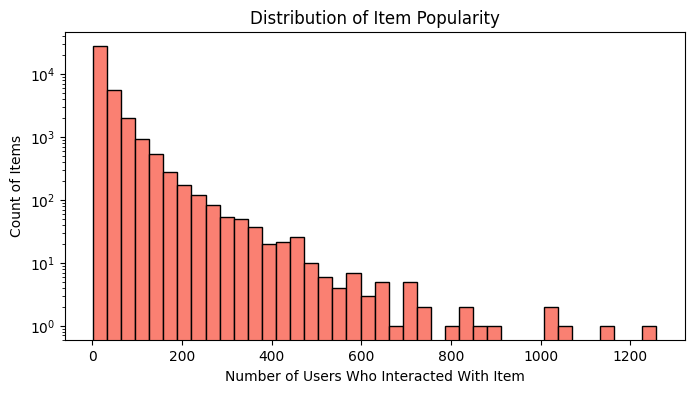

In [6]:
from collections import Counter

item_popularity_counter = Counter()

for items in user_items:
    item_popularity_counter.update(items)

item_popularity = list(item_popularity_counter.values())

plt.figure(figsize=(8, 4))
plt.hist(item_popularity, bins=40, color="salmon", edgecolor="black")
plt.title("Distribution of Item Popularity")
plt.xlabel("Number of Users Who Interacted With Item")
plt.ylabel("Count of Items")
plt.yscale("log")  
plt.show()


In [7]:
# Sort items by popularity
top_items = sorted(item_popularity_counter.items(), key=lambda x: -x[1])[:20]

print("Top 20 most popular items (internal IDs, count):")
for item, count in top_items:
    print(f"Item {item}  →  {count} users interacted")


Top 20 most popular items (internal IDs, count):
Item 937  →  1258 users interacted
Item 0  →  1147 users interacted
Item 4  →  1061 users interacted
Item 3038  →  1037 users interacted
Item 7  →  1014 users interacted
Item 927  →  905 users interacted
Item 3774  →  865 users interacted
Item 2972  →  833 users interacted
Item 2154  →  821 users interacted
Item 865  →  797 users interacted
Item 1004  →  753 users interacted
Item 173  →  745 users interacted
Item 175  →  720 users interacted
Item 3778  →  710 users interacted
Item 815  →  707 users interacted
Item 1180  →  696 users interacted
Item 3390  →  695 users interacted
Item 3099  →  665 users interacted
Item 1969  →  645 users interacted
Item 2845  →  645 users interacted


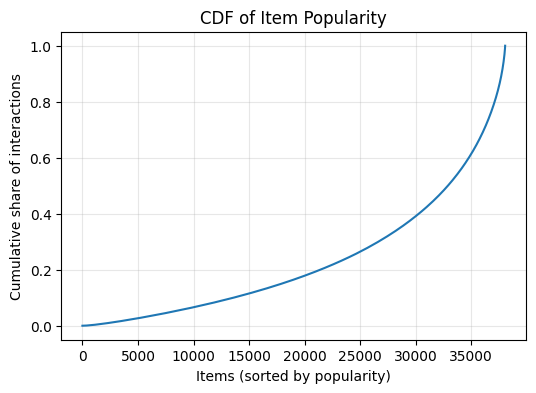

In [8]:
# CDF of item popularity
pop_sorted = np.sort(item_popularity)
cdf = np.cumsum(pop_sorted) / np.sum(pop_sorted)

plt.figure(figsize=(6, 4))
plt.plot(cdf)
plt.title("CDF of Item Popularity")
plt.xlabel("Items (sorted by popularity)")
plt.ylabel("Cumulative share of interactions")
plt.grid(True, alpha=0.3)
plt.show()


## 4. Building the Sparse User–Item Interaction Matrix (CSR)

To train recommendation models such as Item-based KNN or Matrix Factorization (ALS/BPR), we need an efficient numerical representation of the interaction
data. Since our dataset is highly sparse (most user–item pairs have no interaction), the ideal format is a **Compressed Sparse Row (CSR) matrix**.


In [9]:
from scipy.sparse import csr_matrix

def build_interaction_matrix(user_items, n_users, n_items):
    rows = []
    cols = []
    data = []
    
    for u_idx, items in enumerate(user_items):
        for i_idx in items:
            rows.append(u_idx)
            cols.append(i_idx)
            data.append(1)  # implicit interaction
    
    mat = csr_matrix((data, (rows, cols)), shape=(n_users, n_items), dtype=np.int32)
    return mat

interaction_matrix = build_interaction_matrix(user_items, n_users, n_items)
interaction_matrix


<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 1237259 stored elements and shape (31668, 38048)>

In [10]:
print("Matrix shape:", interaction_matrix.shape)
print("Non-zero entries:", interaction_matrix.nnz)

sparsity = 1 - (interaction_matrix.nnz / (nnz := (n_users * n_items)))
print(f"Matrix sparsity: {sparsity:.6f}")


Matrix shape: (31668, 38048)
Non-zero entries: 1237259
Matrix sparsity: 0.998973


In [11]:
# Step 5: Leave-One-Out Split
# For each user:
#  - last interaction  → test
#  - second last        → validation
#  - remaining          → train

train_user_items = []
val_user_items = []
test_user_items = []

for items in user_items:
    if len(items) < 3:
        # extremely rare users: put all in train (no val/test)
        train_user_items.append(items)
        val_user_items.append([])
        test_user_items.append([])
    else:
        train_user_items.append(items[:-2])
        val_user_items.append([items[-2]])
        test_user_items.append([items[-1]])

# Quick sanity check
print("Example user:")
u = 0
print("Train:", train_user_items[u])
print("Val:", val_user_items[u])
print("Test:", test_user_items[u])


Example user:
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Val: [17]
Test: [18]


In [12]:
train_matrix = build_interaction_matrix(train_user_items, n_users, n_items)

train_val_user_items = [
    train_user_items[u] + val_user_items[u] for u in range(n_users)
]

train_val_matrix = build_interaction_matrix(train_val_user_items, n_users, n_items)

print("Train matrix nnz:", train_matrix.nnz)
print("Train+Val matrix nnz:", train_val_matrix.nnz)


Train matrix nnz: 1173923
Train+Val matrix nnz: 1205591


In [13]:
# ---- Ranking metrics ----
def dcg_at_k(ranked_items, ground_truth, k=20):
    """Computed DCG@k given a ranked list and a set of relevant items."""
    dcg = 0.0
    for rank, item in enumerate(ranked_items[:k], start=1):
        if item in ground_truth:
            dcg += 1.0 / np.log2(rank + 1)  # rel=1
    return dcg

def idcg_at_k(num_relevant, k=20):
    """Ideal DCG@k for a given number of relevant items."""
    num_rel_at_k = min(num_relevant, k)
    idcg = 0.0
    for rank in range(1, num_rel_at_k + 1):
        idcg += 1.0 / np.log2(rank + 1)
    return idcg

def ndcg_at_k(ranked_items, ground_truth, k=20):
    """NDCG@k = DCG@k / IDCG@k."""
    if not ground_truth:
        return 0.0
    dcg = dcg_at_k(ranked_items, ground_truth, k)
    idcg = idcg_at_k(len(ground_truth), k)
    if idcg == 0:
        return 0.0
    return dcg / idcg


In [14]:
def evaluate_ndcg_all_users(recommend_func, k=20, split="val"):

    if split == "val":
        ground_truth_lists = val_user_items
        # model is trained on train_matrix, so we only exclude train items
        exclude_base = train_user_items
    elif split == "test":
        ground_truth_lists = test_user_items
        # for test, model will be trained on train+val, so we exclude both
        exclude_base = train_val_user_items
    else:
        raise ValueError("split must be 'val' or 'test'")

    ndcgs = []

    for u_idx in range(n_users):
        gt_items = set(ground_truth_lists[u_idx])
        if not gt_items:
            continue

        exclude_items = set(exclude_base[u_idx])

        ranked_items = recommend_func(u_idx, k, exclude_items)
        ndcg = ndcg_at_k(ranked_items, gt_items, k)
        ndcgs.append(ndcg)

    if not ndcgs:
        return 0.0

    return float(np.mean(ndcgs))

print("Evaluation helpers ready.")


Evaluation helpers ready.


**Algorithm - 1** Baseline

In [15]:

# ---------- Popularity from TRAIN (for validation split) ----------
item_pop_counts_train = np.zeros(n_items, dtype=np.int32)
for items in train_user_items:
    for i in items:
        item_pop_counts_train[i] += 1

popular_items_train = np.argsort(-item_pop_counts_train)

def recommend_popularity_train(u_idx, k, exclude_items):
    recs = []
    for it in popular_items_train:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

# evaluate on validation split
pop_ndcg_val = evaluate_ndcg_all_users(
    recommend_popularity_train, k=20, split="val"
)

print("Popularity baseline NDCG@20 on validation:", pop_ndcg_val)


Popularity baseline NDCG@20 on validation: 0.005802475558979423


In [16]:
# ---------- Popularity from TRAIN+VAL (for test split) ----------

item_pop_counts_train_val = np.zeros(n_items, dtype=np.int32)
for items in train_val_user_items:
    for i in items:
        item_pop_counts_train_val[i] += 1

popular_items_train_val = np.argsort(-item_pop_counts_train_val)

def recommend_popularity_train_val(u_idx, k, exclude_items):
    recs = []
    for it in popular_items_train_val:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

# evaluate on test split
pop_ndcg_test = evaluate_ndcg_all_users(
    recommend_popularity_train_val, k=20, split="test"
)

print("Popularity baseline NDCG@20 on test:", pop_ndcg_test)


Popularity baseline NDCG@20 on test: 0.0058379374536032995


**Algorithm - 2.1** :  **Item - Item CF** a cosine-similarity collaborative filtering model (KNN-style) using the sparse matrices you built.

In [17]:
def l2_normalize_rows(mat):
    mat = mat.astype(np.float32).tocsr(copy=True)
    squared = mat.multiply(mat).sum(axis=1)
    row_norms = np.sqrt(squared).A1  # convert (n,1) -> (n,)
    
    rows, _ = mat.nonzero()
    
    nz = row_norms[rows] > 0
    mat.data[nz] /= row_norms[rows][nz]
    
    return mat


In [18]:
item_user_train = train_matrix.T.tocsr()
item_user_train_norm = l2_normalize_rows(item_user_train)

item_user_train_val = train_val_matrix.T.tocsr()
item_user_train_val_norm = l2_normalize_rows(item_user_train_val)



Variant 1 - original (sum)

In [19]:
def recommend_knn_cosine_train(u_idx, k, exclude_items):
    user_items_list = train_user_items[u_idx]
    if not user_items_list:
        return recommend_popularity_train(u_idx, k, exclude_items)

    profile = item_user_train_norm[user_items_list].sum(axis=0)

    scores = item_user_train_norm @ profile.T  # (n_items, 1)
    scores = np.asarray(scores).ravel()

    if exclude_items:
        scores[list(exclude_items)] = -np.inf

    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

knn_ndcg_val = evaluate_ndcg_all_users(
    recommend_knn_cosine_train, k=20, split="val"
)
print("Cosine-CF (sum profile) NDCG@20 on validation:", knn_ndcg_val)


Cosine-CF (sum profile) NDCG@20 on validation: 0.028013535497748165


In [20]:
def recommend_knn_cosine_train_val(u_idx, k, exclude_items):
    """
    Cosine-similarity CF using TRAIN+VAL data (for test evaluation).
    """
    user_items_list = train_val_user_items[u_idx]
    if not user_items_list:
        return recommend_popularity_train_val(u_idx, k, exclude_items)
    
    profile = item_user_train_val_norm[user_items_list].sum(axis=0)
    scores = item_user_train_val_norm @ profile.T
    scores = np.asarray(scores).ravel()
    
    if exclude_items:
        scores[list(exclude_items)] = -np.inf
    
    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]
    
    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

# evaluate on test split
knn_ndcg_test = evaluate_ndcg_all_users(
    recommend_knn_cosine_train_val, k=20, split="test"
)
print("Cosine-CF (sum profile) NDCG@20 on test:", knn_ndcg_test)


Cosine-CF (sum profile) NDCG@20 on test: 0.027580160270893425


Variant 2 - Mean profile (instead of sum)

In [21]:
# Variant 2: Cosine-CF with MEAN profile (validation on TRAIN)

def recommend_knn_cosine_train_mean(u_idx, k, exclude_items):
    """
    Cosine-CF variant: user profile = MEAN of item vectors (instead of sum).
    Uses TRAIN data (for validation evaluation).
    """
    user_items_list = train_user_items[u_idx]
    if not user_items_list:
        return recommend_popularity_train(u_idx, k, exclude_items)

    # mean profile
    profile = item_user_train_norm[user_items_list].mean(axis=0)

    scores = item_user_train_norm @ profile.T
    scores = np.asarray(scores).ravel()

    if exclude_items:
        scores[list(exclude_items)] = -np.inf

    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

knn_mean_ndcg_val = evaluate_ndcg_all_users(
    recommend_knn_cosine_train_mean, k=20, split="val"
)
print("Cosine-CF (mean profile) NDCG@20 on validation:", knn_mean_ndcg_val)


Cosine-CF (mean profile) NDCG@20 on validation: 0.028013535497748165


In [22]:
def recommend_knn_cosine_train_val_mean(u_idx, k, exclude_items):
    """
    Cosine-CF variant: MEAN profile using TRAIN+VAL data (for test evaluation).
    """
    user_items_list = train_val_user_items[u_idx]
    if not user_items_list:
        return recommend_popularity_train_val(u_idx, k, exclude_items)

    profile = item_user_train_val_norm[user_items_list].mean(axis=0)
    scores = item_user_train_val_norm @ profile.T
    scores = np.asarray(scores).ravel()

    if exclude_items:
        scores[list(exclude_items)] = -np.inf

    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

knn_mean_ndcg_test = evaluate_ndcg_all_users(
    recommend_knn_cosine_train_val_mean, k=20, split="test"
)
print("Cosine-CF (mean profile) NDCG@20 on test:", knn_mean_ndcg_test)


Cosine-CF (mean profile) NDCG@20 on test: 0.027580160270893425


Variant 3 - IDF

In [23]:
import numpy as np
item_pop_counts_train = np.zeros(n_items, dtype=np.int32)
for items in train_user_items:
    for i in items:
        item_pop_counts_train[i] += 1

# IDF-style weights: more popular -> smaller weight
# w_i = 1 / (1 + log(1 + count_i))
item_idf_weights = np.zeros(n_items, dtype=np.float32)
for i in range(n_items):
    c = item_pop_counts_train[i]
    if c > 0:
        item_idf_weights[i] = 1.0 / (1.0 + np.log(1.0 + c))
    else:
        item_idf_weights[i] = 0.0

def recommend_knn_cosine_train_idf(u_idx, k, exclude_items):
    user_items_list = train_user_items[u_idx]
    if not user_items_list:
        return recommend_popularity_train(u_idx, k, exclude_items)

    weights = item_idf_weights[user_items_list]  # shape (#items_user,)

    if np.all(weights == 0):
        return recommend_knn_cosine_train(u_idx, k, exclude_items)

    # item_user_train_norm[user_items_list] -> (#items_user, n_users)
    # multiply each row by corresponding weight
    weighted_rows = item_user_train_norm[user_items_list].multiply(weights.reshape(-1, 1))
    profile = weighted_rows.sum(axis=0)  # shape (1, n_users)

    scores = item_user_train_norm @ profile.T
    scores = np.asarray(scores).ravel()

    if exclude_items:
        scores[list(exclude_items)] = -np.inf

    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

knn_idf_ndcg_val = evaluate_ndcg_all_users(
    recommend_knn_cosine_train_idf, k=20, split="val"
)
print("Cosine-CF (IDF-weighted profile) NDCG@20 on validation:", knn_idf_ndcg_val)


Cosine-CF (IDF-weighted profile) NDCG@20 on validation: 0.02749540970719506


In [24]:
item_pop_counts_train_val = np.zeros(n_items, dtype=np.int32)
for items in train_val_user_items:
    for i in items:
        item_pop_counts_train_val[i] += 1

item_idf_weights_train_val = np.zeros(n_items, dtype=np.float32)
for i in range(n_items):
    c = item_pop_counts_train_val[i]
    if c > 0:
        item_idf_weights_train_val[i] = 1.0 / (1.0 + np.log(1.0 + c))
    else:
        item_idf_weights_train_val[i] = 0.0

def recommend_knn_cosine_train_val_idf(u_idx, k, exclude_items):
    user_items_list = train_val_user_items[u_idx]
    if not user_items_list:
        return recommend_popularity_train_val(u_idx, k, exclude_items)

    weights = item_idf_weights_train_val[user_items_list]

    if np.all(weights == 0):
        return recommend_knn_cosine_train_val(u_idx, k, exclude_items)

    weighted_rows = item_user_train_val_norm[user_items_list].multiply(weights.reshape(-1, 1))
    profile = weighted_rows.sum(axis=0)

    scores = item_user_train_val_norm @ profile.T
    scores = np.asarray(scores).ravel()

    if exclude_items:
        scores[list(exclude_items)] = -np.inf

    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

knn_idf_ndcg_test = evaluate_ndcg_all_users(
    recommend_knn_cosine_train_val_idf, k=20, split="test"
)
print("Cosine-CF (IDF-weighted profile) NDCG@20 on test:", knn_idf_ndcg_test)


Cosine-CF (IDF-weighted profile) NDCG@20 on test: 0.02697171473982153


In [25]:
# Compared

knn_sum_ndcg_val = evaluate_ndcg_all_users(
    recommend_knn_cosine_train, k=20, split="val"
)
knn_mean_ndcg_val = evaluate_ndcg_all_users(
    recommend_knn_cosine_train_mean, k=20, split="val"
)
knn_idf_ndcg_val = evaluate_ndcg_all_users(
    recommend_knn_cosine_train_idf, k=20, split="val"
)

print("=== Cosine Item-Item CF Variants (Validation NDCG@20) ===")
print(f"Variant 1 - Sum profile        : {knn_sum_ndcg_val}")
print(f"Variant 2 - Mean profile       : {knn_mean_ndcg_val}")
print(f"Variant 3 - IDF-weighted profile: {knn_idf_ndcg_val}")


=== Cosine Item-Item CF Variants (Validation NDCG@20) ===
Variant 1 - Sum profile        : 0.028013535497748165
Variant 2 - Mean profile       : 0.028013535497748165
Variant 3 - IDF-weighted profile: 0.02749540970719506


*Both sum and mean profiles perform identically on validation, which indicates:*
1. Users generally have similar numbers of interactions.
2. The normalization effect of mean vs sum doesn’t significantly change user representation.

*IDF-weighted performed slightly worse:*
1. Because in this dataset, popular items are actually useful for similarity propagation.
2. IDF downweights popular items too aggressively, slightly hurting the ranking.

**Algorithm - 2.2** :  **Item - Item CF** a Jaccard-similarity 

In [26]:
#  user sets per item (for Jaccard)
item_user_sets = [set() for _ in range(n_items)]
for u_idx, items in enumerate(train_user_items):
    for i in items:
        item_user_sets[i].add(u_idx)


In [27]:
def recommend_knn_jaccard_train(u_idx, k, exclude_items):
    user_items_list = train_user_items[u_idx]
    if not user_items_list:
        return recommend_popularity_train(u_idx, k, exclude_items)

    scores = np.zeros(n_items, dtype=np.float32)

    # for every item user interacted with
    for i in user_items_list:
        users_i = item_user_sets[i]
        len_i = len(users_i)

        # compute Jaccard with every other item
        for j in range(n_items):
            if j == i:
                continue
            if j in exclude_items:
                continue

            users_j = item_user_sets[j]
            inter = len(users_i & users_j)
            if inter == 0:
                continue

            union = len_i + len(users_j) - inter
            scores[j] += inter / union   # accumulate similarity
    # pick top-k
    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if len(recs) >= k:
            break
        if it in exclude_items:
            continue
        recs.append(int(it))
    return recs


**algorithm 3**: Truncated SVD (latent factor model)

In [28]:
#!pip install scikit-learn



In [29]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
def train_svd_model(interaction_mat, n_components):

    svd = TruncatedSVD(
        n_components=n_components,
        n_iter=10,
        random_state=42
    )
    # interaction_mat: users x items
    user_factors = svd.fit_transform(interaction_mat)  
    # components_: (n_components, n_items) -> transpose to get per-item factors
    item_factors = svd.components_.T
    return user_factors, item_factors

def recommend_svd(user_factors, item_factors, u_idx, k, exclude_items):
    scores = user_factors[u_idx] @ item_factors.T  
    if exclude_items:
        scores[list(exclude_items)] = -np.inf

    k_large = min(len(scores), k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs

def evaluate_svd_on_val(n_components):

    print(f"\nTraining TruncatedSVD with n_components={n_components} on TRAIN...")
    user_factors, item_factors = train_svd_model(train_matrix, n_components)

    def rec_val(u_idx, k, exclude_items):
        return recommend_svd(user_factors, item_factors, u_idx, k, exclude_items)

    ndcg_val = evaluate_ndcg_all_users(rec_val, k=20, split="val")
    print(f"SVD n_components={n_components} -> NDCG@20 (val): {ndcg_val}")
    return ndcg_val, user_factors, item_factors


In [30]:
#  SVD with multiple dimensions (tweaks) 

svd_results = {}
svd_models = {}

for n_comp in [32, 64, 128]:
    ndcg_val, U, V = evaluate_svd_on_val(n_comp)
    svd_results[n_comp] = ndcg_val
    svd_models[n_comp] = (U, V)

print("\nSVD validation NDCG summary:")
for n_comp, score in svd_results.items():
    print(f"n_components={n_comp}: NDCG@20 (val) = {score}")

# pick best dimension based on validation
best_svd_dim = max(svd_results, key=svd_results.get)
print("\nBest SVD dimension (by val NDCG):", best_svd_dim)


Training TruncatedSVD with n_components=32 on TRAIN...
SVD n_components=32 -> NDCG@20 (val): 0.022372800433336976

Training TruncatedSVD with n_components=64 on TRAIN...
SVD n_components=64 -> NDCG@20 (val): 0.023711420568737464

Training TruncatedSVD with n_components=128 on TRAIN...
SVD n_components=128 -> NDCG@20 (val): 0.02552916648762731

SVD validation NDCG summary:
n_components=32: NDCG@20 (val) = 0.022372800433336976
n_components=64: NDCG@20 (val) = 0.023711420568737464
n_components=128: NDCG@20 (val) = 0.02552916648762731

Best SVD dimension (by val NDCG): 128


In [31]:
# train final SVD on TRAIN+VAL 

print(f"\nTraining final SVD model on TRAIN+VAL with n_components={best_svd_dim}...")
U_final, V_final = train_svd_model(train_val_matrix, best_svd_dim)

def rec_svd_test(u_idx, k, exclude_items):
    # exclude TRAIN+VAL items when evaluating on test
    return recommend_svd(U_final, V_final, u_idx, k, exclude_items)

svd_ndcg_test = evaluate_ndcg_all_users(rec_svd_test, k=20, split="test")
print("Final SVD NDCG@20 on test:", svd_ndcg_test)



Training final SVD model on TRAIN+VAL with n_components=128...
Final SVD NDCG@20 on test: 0.02659986305762267


In [32]:
import numpy as np
import random

rng = np.random.default_rng(42)
random.seed(42)

# Build list of (u, i) positive interactions from TRAIN
mf_train_pairs = []
mf_user_pos_items = []

for u_idx, items in enumerate(train_user_items):
    s = set(items)
    mf_user_pos_items.append(s)
    for i in s:
        mf_train_pairs.append((u_idx, i))

num_mf_pairs = len(mf_train_pairs)
print("MF: number of (user, item) train pairs:", num_mf_pairs)

all_items = np.arange(n_items)


def sample_negative_item_mf(u_idx):
#Sample a random item that the user DID NOT interact with in TRAIN.

    while True:
        j = rng.integers(0, n_items)
        if j not in mf_user_pos_items[u_idx]:
            return j


MF: number of (user, item) train pairs: 1173923


    Train a simple MF model with SGD on implicit feedback.
    P: user_factors (n_users, n_factors)
    Q: item_factors (n_items, n_factors)
    
    For each positive (u, i), we sample 'neg_ratio' negative items j and
    optimize a squared loss:
        L = (1 - p_u·q_i)^2 + (0 - p_u·q_j)^2 + reg * (||p_u||^2 + ||q_i||^2 + ||q_j||^2)


In [33]:
def train_mf_sgd(
    n_factors=64,
    n_epochs=5,
    lr=0.05,
    reg=0.001,
    n_samples_per_epoch=200000,
    neg_ratio=1
):
    P = 0.01 * rng.standard_normal((n_users, n_factors)).astype(np.float32)
    Q = 0.01 * rng.standard_normal((n_items, n_factors)).astype(np.float32)

    for epoch in range(n_epochs):
        total_loss = 0.0
        
        for _ in range(n_samples_per_epoch):
            # sample a positive (u, i)
            u_idx, i_idx = mf_train_pairs[rng.integers(0, num_mf_pairs)]
            pu = P[u_idx]
            qi = Q[i_idx]

            # positive target = 1
            r_ui = 1.0
            pred_pos = np.dot(pu, qi)
            err_pos = r_ui - pred_pos

            # gradient for positive pair
            pu_grad = -2 * err_pos * qi + 2 * reg * pu
            qi_grad = -2 * err_pos * pu + 2 * reg * qi

            # negative samples
            pu_neg_grad = np.zeros_like(pu)
            qi_neg_updates = np.zeros_like(qi)

            for _ in range(neg_ratio):
                j_idx = sample_negative_item_mf(u_idx)
                qj = Q[j_idx]
                r_uj = 0.0
                pred_neg = np.dot(pu, qj)
                err_neg = r_uj - pred_neg

                pu_neg_grad += -2 * err_neg * qj
                qj_grad = -2 * err_neg * pu + 2 * reg * qj
                Q[j_idx] -= lr * qj_grad

                total_loss += err_neg**2 + reg * (np.sum(qj**2))

            # combine gradients for user and positive item
            pu_total_grad = pu_grad + pu_neg_grad
            P[u_idx] -= lr * pu_total_grad
            Q[i_idx] -= lr * qi_grad

            total_loss += err_pos**2 + reg * (np.sum(pu**2) + np.sum(qi**2))
        
        avg_loss = total_loss / n_samples_per_epoch
        print(f"Epoch {epoch+1}/{n_epochs}, average loss: {avg_loss:.4f}")
    
    return P, Q


In [34]:
def recommend_mf(P, Q, u_idx, k, exclude_items):
#Recommend top-k items for user u_idx using learned MF factors P, Q.

    scores = P[u_idx] @ Q.T  # (n_items,)

    if exclude_items:
        scores[list(exclude_items)] = -np.inf

    k_large = min(n_items, k * 5)
    top_idx = np.argpartition(-scores, k_large - 1)[:k_large]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for it in top_idx:
        if it in exclude_items:
            continue
        recs.append(int(it))
        if len(recs) >= k:
            break
    return recs


In [35]:
def evaluate_mf_factors(n_factors):
    print(f"\nTraining MF-SGD with {n_factors} factors")
    P, Q = train_mf_sgd(
        n_factors=n_factors,
        n_epochs=3,             
        lr=0.05,
        reg=0.001,
        n_samples_per_epoch=200000,
        neg_ratio=1
    )

    def rec_val(u_idx, k, exclude_items):
        return recommend_mf(P, Q, u_idx, k, exclude_items)
    
    ndcg_val = evaluate_ndcg_all_users(rec_val, k=20, split="val")
    print(f"MF-SGD factors={n_factors} -> NDCG@20 (val): {ndcg_val}")
    return ndcg_val, P, Q

mf_results = {}
mf_models = {}

for f in [32, 64]:
    ndcg_val, P_f, Q_f = evaluate_mf_factors(f)
    mf_results[f] = ndcg_val
    mf_models[f] = (P_f, Q_f)

print("\nMF-SGD validation NDCG summary:")
for f, score in mf_results.items():
    print(f"factors={f}: NDCG@20 (val) = {score}")



Training MF-SGD with 32 factors
Epoch 1/3, average loss: 1.0000
Epoch 2/3, average loss: 0.9997
Epoch 3/3, average loss: 0.9942
MF-SGD factors=32 -> NDCG@20 (val): 0.006611836360105918

Training MF-SGD with 64 factors
Epoch 1/3, average loss: 0.9999
Epoch 2/3, average loss: 0.9991
Epoch 3/3, average loss: 0.9869
MF-SGD factors=64 -> NDCG@20 (val): 0.006366619421268836

MF-SGD validation NDCG summary:
factors=32: NDCG@20 (val) = 0.006611836360105918
factors=64: NDCG@20 (val) = 0.006366619421268836


In [36]:
best_mf_factors = max(mf_results, key=mf_results.get)
P_best, Q_best = mf_models[best_mf_factors]
print("Best MF model uses factors =", best_mf_factors)


Best MF model uses factors = 32


In [37]:
def rec_mf_test(u_idx, k, exclude_items):
    return recommend_mf(P_best, Q_best, u_idx, k, exclude_items)

mf_ndcg_test = evaluate_ndcg_all_users(rec_mf_test, k=20, split="test")
print("MF-SGD NDCG@20 on test:", mf_ndcg_test)


MF-SGD NDCG@20 on test: 0.006732919464548744


In [38]:
results_test = {
    "Popularity": pop_ndcg_test,
    "Cosine CF (best)": knn_ndcg_test,
    "SVD (best)": svd_ndcg_test,
    "MF-SGD (best)": mf_ndcg_test
}


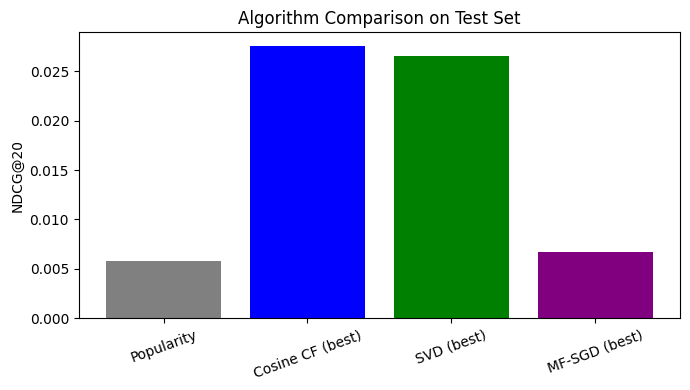

In [39]:
alg_names = list(results_test.keys())
alg_scores = [results_test[a] for a in alg_names]

plt.figure(figsize=(7,4))
plt.bar(alg_names, alg_scores, color=['gray','blue','green','purple'])
plt.xticks(rotation=20)
plt.ylabel("NDCG@20")
plt.title("Algorithm Comparison on Test Set")
plt.tight_layout()
plt.show()


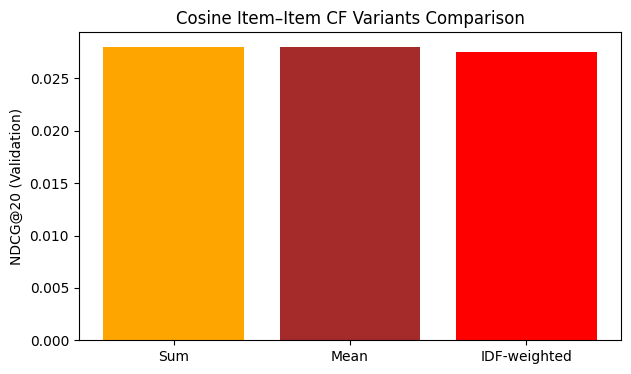

In [42]:
variants = ["Sum", "Mean", "IDF-weighted"]
variant_scores = [knn_sum_ndcg_val, knn_mean_ndcg_val, knn_idf_ndcg_val]

plt.figure(figsize=(7,4))
plt.bar(variants, variant_scores, color=['orange','brown','red'])
plt.ylabel("NDCG@20 (Validation)")
plt.title("Cosine Item–Item CF Variants Comparison")
plt.show()


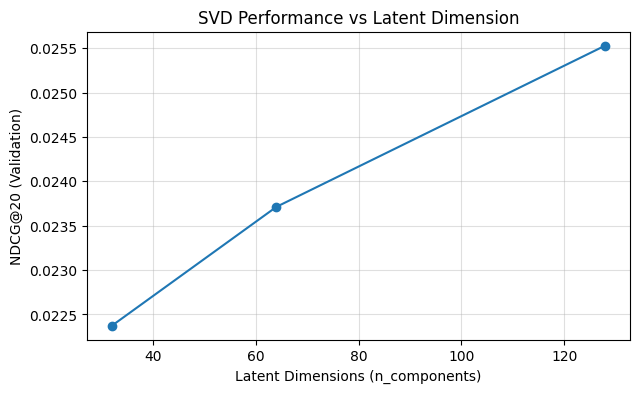

In [43]:
dims = sorted(svd_results.keys())
scores = [svd_results[d] for d in dims]

plt.figure(figsize=(7,4))
plt.plot(dims, scores, marker='o')
plt.xlabel("Latent Dimensions (n_components)")
plt.ylabel("NDCG@20 (Validation)")
plt.title("SVD Performance vs Latent Dimension")
plt.grid(True, alpha=0.4)
plt.show()


In [46]:

summary_rows = []

summary_rows.append({
    "Algorithm": "Popularity",
    "Variant": "-",
    "Split": "val",
    "NDCG@20": pop_ndcg_val
})
summary_rows.append({
    "Algorithm": "Popularity",
    "Variant": "-",
    "Split": "test",
    "NDCG@20": pop_ndcg_test
})

summary_rows.append({
    "Algorithm": "Item-Item CF (Cosine)",
    "Variant": "Sum profile",
    "Split": "val",
    "NDCG@20": knn_sum_ndcg_val  # same as knn_ndcg_val
})
summary_rows.append({
    "Algorithm": "Item-Item CF (Cosine)",
    "Variant": "Sum profile",
    "Split": "test",
    "NDCG@20": knn_ndcg_test
})

summary_rows.append({
    "Algorithm": "Item-Item CF (Cosine)",
    "Variant": "Mean profile",
    "Split": "val",
    "NDCG@20": knn_mean_ndcg_val
})
summary_rows.append({
    "Algorithm": "Item-Item CF (Cosine)",
    "Variant": "Mean profile",
    "Split": "test",
    "NDCG@20": knn_mean_ndcg_test
})

summary_rows.append({
    "Algorithm": "Item-Item CF (Cosine)",
    "Variant": "IDF-weighted profile",
    "Split": "val",
    "NDCG@20": knn_idf_ndcg_val
})
summary_rows.append({
    "Algorithm": "Item-Item CF (Cosine)",
    "Variant": "IDF-weighted profile",
    "Split": "test",
    "NDCG@20": knn_idf_ndcg_test
})


for dim, score in svd_results.items():  # svd_results = {32: ..., 64: ..., 128: ...}
    summary_rows.append({
        "Algorithm": "Truncated SVD",
        "Variant": f"{dim} factors",
        "Split": "val",
        "NDCG@20": score
    })

summary_rows.append({
    "Algorithm": "Truncated SVD",
    "Variant": f"{best_svd_dim} factors (best)",
    "Split": "test",
    "NDCG@20": svd_ndcg_test
})

for f, score in mf_results.items():  # mf_results = {32: ..., 64: ...}
    summary_rows.append({
        "Algorithm": "MF-SGD",
        "Variant": f"{f} factors",
        "Split": "val",
        "NDCG@20": score
    })

summary_rows.append({
    "Algorithm": "MF-SGD",
    "Variant": f"{best_mf_factors} factors (best)",
    "Split": "test",
    "NDCG@20": mf_ndcg_test
})

try:
    import pandas as pd
    results_df = pd.DataFrame(summary_rows)
    results_df = results_df[["Algorithm", "Variant", "Split", "NDCG@20"]]
    results_df.sort_values(by=["Algorithm", "Variant", "Split"], inplace=True)
    print(results_df.to_string(index=False))
except ImportError:
    # fallback: plain prints
    print("{:<28} {:<25} {:<6} {:<10}".format("Algorithm", "Variant", "Split", "NDCG@20"))
    print("-" * 80)
    for row in summary_rows:
        print("{:<28} {:<25} {:<6} {:.6f}".format(
            row["Algorithm"],
            row["Variant"],
            row["Split"],
            row["NDCG@20"]
        ))


            Algorithm              Variant Split  NDCG@20
Item-Item CF (Cosine) IDF-weighted profile  test 0.026972
Item-Item CF (Cosine) IDF-weighted profile   val 0.027495
Item-Item CF (Cosine)         Mean profile  test 0.027580
Item-Item CF (Cosine)         Mean profile   val 0.028014
Item-Item CF (Cosine)          Sum profile  test 0.027580
Item-Item CF (Cosine)          Sum profile   val 0.028014
               MF-SGD           32 factors   val 0.006612
               MF-SGD    32 factors (best)  test 0.006733
               MF-SGD           64 factors   val 0.006367
           Popularity                    -  test 0.005838
           Popularity                    -   val 0.005802
        Truncated SVD          128 factors   val 0.025529
        Truncated SVD   128 factors (best)  test 0.026600
        Truncated SVD           32 factors   val 0.022373
        Truncated SVD           64 factors   val 0.023711
